# Mangle spectra

In [1]:
import os
#COCO_PATH=os.environ['COCO_PATH']
COCO_PATH="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/"
DATALC_PATH = COCO_PATH+"/Inputs/Photometry/4_LCs_late_extrapolated/"
DATASPEC_PATH = COCO_PATH+"/Inputs/Spectroscopy/"

DATAINFO_PATH= COCO_PATH+"Inputs/SNe_Info/"
FILTER_PATH = COCO_PATH+"Inputs/Filters/"

OUTPUT_DIR = COCO_PATH+"Outputs/"

import sys
sys.path.insert(0, COCO_PATH+'what_the_flux/')
import what_the_flux as wtf

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from scipy import interpolate
from scipy import integrate
import scipy.optimize as opt
import json

import george
from george.kernels import ExpSquaredKernel, ConstantKernel, Matern32Kernel

import matplotlib.cm as cm
import scipy
%matplotlib inline

In [3]:
color_dict = {'Bessell_U': 'blue', 'Bessell_B': 'royalblue','Bessell_V':  'limegreen',
              'Bessell_R':  'red', 'Bessell_I':  'mediumvioletred',
              'sdss_g':'darkgreen','ptf_g':'darkgreen', "sdss_g'":'darkgreen','sdss_i':'indianred',
              "sdss_i'":'indianred','sdss_r': 'darkred', "sdss_r'":'darkred','sdss_z':'sienna', "sdss_z'":'sienna',
              'sdss_u': 'darkblue', "sdss_u'": 'darkblue', 'Y':'salmon','H':'darkred', 'J':  'k',
              'Ks':  'brown','K':  'brown', 'swift_UVW1':'indigo', 'swift_UVW2':'darkblue',
               'swift_UVM2':'darkmagenta','swift_U':'plum','swift_V':'teal','swift_B':'powderblue'}

mark_dict = {'Bessell_U': 'o','Bessell_B': 'o', 'Bessell_V':'o', 'Bessell_R':'o', 'Bessell_I': 'o', 
             'sdss_g':'s','ptf_g':'s', "sdss_g'":'s', 'sdss_i':'s', "sdss_i'":'s',
                'sdss_r':'s', "sdss_r'":'s', 'sdss_z':'s', "sdss_z'":'s', 'sdss_u': 's', "sdss_u'": 's',
                'Y':  'o','H':  'o', 'J':  'o', 'Ks':  'o','K':  'o',
                'swift_UVW1':'D', 'swift_UVW2':'D', 'swift_UVM2':'D', 'swift_U':'D',
                'swift_V':'D', 'swift_B':'D'}

CSP_SNe = ['SN2004fe', 'SN2005bf', 'SN2006V', 'SN2007C', 'SN2007Y',
           'SN2009bb',  'SN2008aq', 'SN2006T', 'SN2004gq', 'SN2004gt',
           'SN2004gv','SN2006ep', 'SN2008fq', 'SN2006aa']

#exclude_filt = ['H', 'J', 'K', 'Ks','KS', 'Y']
#exclude_filt = ['KS']

In [5]:
color_dict = {
    'RetroCam_J': 'black',
    'Swope_i': 'indianred',
    'ACS_WFC_F625W': 'orange',
    'UVOT_U': 'teal',
    'DECam_i': 'orangered',
    'RetroCam_H': 'maroon',
    'DECam_z': 'darkslategray',
    'DECam_Y': 'goldenrod',
    'RetroCam_Y': 'salmon',
    'FourStar_H': 'darkred',
    'EFOSC2_r': 'tomato',
    'IMACS_V2': 'mediumseagreen',
    'Sinistro_z': 'sienna',
    'EFOSC2_g': 'darkcyan',
    'FourStar_J': 'black',
    'IMACS_V1': 'mediumblue',
    'ACS_WFC_F475W': 'dodgerblue',
    'IMACS_r': 'darkred',
    'SkyMapper_g': 'forestgreen',
    'EFOSC2_U': 'blue',
    'LRIS_I': 'mediumvioletred',
    'Sinistro_i': 'firebrick',
    'SkyMapper_r': 'deeppink',
    'EFOSC2_V': 'limegreen',
    'SOFI_H': 'firebrick',
    'Sinistro_g': 'darkgreen',
    'LRIS_g': 'seagreen',
    'SkyMapper_i': 'slateblue',
    'WFC3_UVIS1_F336W': 'turquoise',
    'Sinistro_r': 'crimson',
    'WFC3_IR_F160W': 'purple',
    'FourStar_Ks': 'brown',
    'Sinistro_V': 'mediumaquamarine',
    'Sinistro_w': 'gray',
    'FourStar_J1': 'dimgray',
    'SOFI_Ks': 'saddlebrown',
    'EFOSC2_i': 'indigo',
    'DECam_u': 'navy',
    'Swope_V': 'green',
    'Swope_B': 'royalblue',
    'ACS_WFC_F850W': 'peru',
    'DECam_r': 'darkorange',
    'WFC3_IR_F110W': 'darkorchid',
    'Swope_g': 'darkseagreen',
    'Swope_r': 'red',
    'ACS_WFC_F775W': 'chocolate',
    'DECam_g': 'mediumspringgreen'
}

exclude_filt = []
#exclude_filt = ['H', 'J', 'K', 'Ks','KS', 'Y', 'FourStar_H', 'FourStar_J', 'FourStar_Ks', 'FourStar_J1',
#                'RetroCam_Y', 'RetroCam_H', 'RetroCam_J', 'SOFI_H', 'SOFI_Ks']

mark_dict = {
    # Swope
    'Swope_i': 'o',
    'Swope_V': 'o',
    'Swope_B': 'o',
    'Swope_r': 'o',
    'Swope_g': 'o',

    # FourStar
    'FourStar_H': 'o',
    'FourStar_J': 'o',
    'FourStar_Ks': 'o',
    'FourStar_J1': 'o',

    # RetroCam
    'RetroCam_Y': 'o',
    'RetroCam_H': 'o',
    'RetroCam_J': 'o',

    # SOFI
    'SOFI_H': 'o',
    'SOFI_Ks': 'o',

    # Sinistro
    'Sinistro_w': 's',
    'Sinistro_g': 's',
    'Sinistro_r': 's',
    'Sinistro_i': 's',
    'Sinistro_z': 's',
    'Sinistro_V': 's',

    # EFOSC2
    'EFOSC2_V': 'D',
    'EFOSC2_U': 'D',
    'EFOSC2_g': 'D',
    'EFOSC2_r': 'D',
    'EFOSC2_i': 'D',

    # LRIS
    'LRIS_I': 'D',
    'LRIS_g': 'D',

    # IMACS
    'IMACS_r': 's',
    'IMACS_V1': 's',
    'IMACS_V2': 's',

    # DECam
    'DECam_i': '^',   # triangle up
    'DECam_z': '^',
    'DECam_Y': '^',
    'DECam_u': '^',
    'DECam_r': '^',
    'DECam_g': '^',

    # ACS_WFC
    'ACS_WFC_F625W': 'v',   # triangle down
    'ACS_WFC_F475W': 'v',
    'ACS_WFC_F850W': 'v',
    'ACS_WFC_F775W': 'v',

    # WFC3
    'WFC3_UVIS1_F336W': '*',   # star
    'WFC3_IR_F160W': '*',
    'WFC3_IR_F110W': '*',

    # SkyMapper
    'SkyMapper_g': 'P',   # plus-filled
    'SkyMapper_r': 'P',
    'SkyMapper_i': 'P',

    # UVOT
    'UVOT_U': 'X',   # cross
}

In [6]:
def err_to_log10(flux, err_flux):
    flux=np.array(flux, dtype=float)
    err_flux=np.array(err_flux, dtype=float)
    return 1./np.log(10.) * err_flux/flux

def err_from_log10(logflux, logerr_flux):
    return np.log(10.) * 10**logflux * logerr_flux



In [7]:
def calc_lam_avg(wls, transmission):
    return (integrate.trapezoid(transmission*wls, wls)/\
            integrate.trapezoid(transmission, wls))

def calc_lam_eff(wls, transmission, flux):
    return (integrate.trapezoid(transmission*flux*wls, wls)/\
            integrate.trapezoid(transmission*flux, wls))

def prop_err_div(x,y,sig_x,sig_y):
    return ((sig_x/y)**2  +  ((x*sig_y)/y**2)**2 )**0.5

### Build the Class

In [8]:
kernel_divide = 800

In [9]:
class SingleSpectrumClass():
    """Class to load and mangle a single spectrum:
    """
    
    def __init__(self, snname, spec_file=None, verbose=False):
        """
        """
        self.snname = snname
        self.check_results_folder()
        
        if spec_file is None:
            print ("Choose one spec_file from this list:")
            print (len(self.get_spec_list()))
        else:
            self.spec_file = spec_file
            self.load_manglingfile()
        
        # Adding in the filters min/max mjd dictionary load-in
        if not hasattr(self, 'filter_mjd_dict'):
            mjd_dict_path = '/Users/ravkaur/Desktop/research/kilonova-SED/AT2017gfo_mjd_ranges_dict.json'
            with open(mjd_dict_path, 'r') as f:
                self.filter_mjd_dict = json.load(f)

    def check_results_folder(self):
        results_directory = OUTPUT_DIR+'/%s/'%self.snname
        if not os.path.exists(results_directory):
            print ("I cant mangle a spectrum if I theres no fitted LC yet")
        else: self.results_mainpath = results_directory

    def load_manglingfile(self):
        if not hasattr(self, "results_mainpath"):
            self.check_results_folder()
        else:
            mangling_file = OUTPUT_DIR+'/%s/'%self.snname+'fitted_phot4mangling_%s.dat'%self.snname
            if not os.path.isfile(mangling_file):
                print ("I need the file with fitted photometry in order to mangle a spectrum")
            else:
                phot4mangling = pd.read_csv(mangling_file, sep='\t')
                #print (phot4mangling)#self.phot4mangling = 
                self.phot4mangling = (phot4mangling[phot4mangling['spec_file']== self.spec_file])
                self.avail_filters = [col.replace('_fitflux','') for col in phot4mangling.columns\
                                      if col[-8:]=='_fitflux']
                
    def load_raw_spec(self):
        if not hasattr(self, "phot4mangling"):
            self.load_manglingfile()
        else:
            raw_spec = np.genfromtxt(self.spec_file,\
                                     dtype=None, encoding="utf-8", names=['wls', 'flux', 'fluxerr'])
            raw_spec = raw_spec[(~np.isnan(raw_spec['flux']))&(~np.isnan(raw_spec['wls']))]
            raw_spec['flux'] = raw_spec['flux']
            self.raw_spec = raw_spec
        return raw_spec
        
    def get_spec_list(self, verbose=False):
        phase_list_file = DATASPEC_PATH + '2_spec_lists_smoothed/' + self.snname+'.list'
        try: 
            parse_phase = np.genfromtxt(phase_list_file, dtype=None, encoding="utf-8")
            spec_list = parse_phase['f2']
            mjd_list = parse_phase['f0']
            mjd_fake_phase = parse_phase['f1']
            if verbose: 
                for mjd,i in zip(spec_list, mjd_list): 
                    print (mjd, i)
            return np.array(spec_list)
        except: 
            print ('I looked into %s and I found NO spectra? Ooops'%phase_list_file)
            return np.array([])
  
    def check_spec_manglingphot(self):
        all_specs = self.get_spec_list()
        mangling_file = OUTPUT_DIR+'/%s/'%self.snname+'fitted_phot4mangling_%s.dat'%self.snname
        phot4mangling = pd.read_csv(mangling_file, sep='\t')
        for spec_file in all_specs:
            file_name = spec_file
            mask = phot4mangling['spec_file'].values == file_name
            if len(phot4mangling[mask])==0:
                print ('There.s no magnling photometry fro this. Are you sure nothing went wrong in the step 4_LCfit?', spec_file)

    def create_mangledspec_folder(self):
        mangledspec_directory = OUTPUT_DIR+'/%s/'%self.snname+'/mangled_spectra/'
        if not os.path.exists(mangledspec_directory):
            os.makedirs(mangledspec_directory)
        self.mangledspec_path = mangledspec_directory

    
    def band_flux(self, filter_name, type_spec2use=False):
        """ type_spec2use choose one among: 
                raw_spec, 
                mangled  """
        
        if (not hasattr(self, 'raw_spec'))&(type_spec2use=='raw_spec'):
            print ("Load the spectrum first calling self.load_raw_spec() and self.break_degeneracy()")
        elif (hasattr(self, 'raw_spec'))&(type_spec2use=='raw_spec'):
              spec_flux = self.raw_spec
              #print("raw_spec shape:", self.raw_spec.shape)
              #print("raw_spec type:", type(self.raw_spec))
              #print("raw_spec contents:", self.raw_spec[:5])
        elif (not hasattr(self, 'mangled_spec'))&(type_spec2use=='mangled'):
            print ("Mangled spectrum not available. Mangle the spectrum first calling self.mangle_spectrum()")
        elif (hasattr(self, 'mangled_spec'))&(type_spec2use=='mangled'):
              spec_flux = self.mangled_spec
        #print("Shape of spec_flux:", spec_flux.shape)
        
        #print ('type_spec2use', type_spec2use, min(spec_flux['flux']))

        if 'swift' in filter_name:
            filt_transm = np.genfromtxt(FILTER_PATH+'/Swift/%s.dat'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])
        elif self.snname in CSP_SNe:
            filt_transm = np.genfromtxt(FILTER_PATH+'/Site3_CSP/%s.txt'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])
        else:
            filt_transm = np.genfromtxt(FILTER_PATH+'/GeneralFilters/%s.dat'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])

        min_wls = min(filt_transm['wls'])
        max_wls = max(filt_transm['wls'])
        
        lam_avg = calc_lam_avg(filt_transm['wls'], filt_transm['flux']) 

        cut_spec = (spec_flux['wls']>min_wls)&\
                     (spec_flux['wls']<max_wls)
        cut_raw_spec = spec_flux[cut_spec].copy()
        #print("spec_flux shape:", spec_flux.shape)
        
        filt_transm_interp_func = interpolate.interp1d(filt_transm['wls'], 
                                                       filt_transm['flux'], 
                                                       kind='linear')
        filt_transm_interp = filt_transm_interp_func(cut_raw_spec['wls'])
        filt_transm_interp_xLambda = filt_transm_interp*cut_raw_spec['wls']
        
        lam_eff = calc_lam_eff(cut_raw_spec['wls'], 
                                        filt_transm_interp, 
                                        cut_raw_spec['flux']) 

        raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_raw_spec['flux'], cut_raw_spec['wls'])/\
                 integrate.trapezoid(filt_transm_interp_xLambda, cut_raw_spec['wls'])
        raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_raw_spec['fluxerr'])**2,
                                        cut_raw_spec['wls']))**0.5/\
                 integrate.trapezoid(filt_transm_interp_xLambda, cut_raw_spec['wls'])

        if type_spec2use=='mangled':  
            return lam_eff, raw_phot
        else: 
            return lam_avg, lam_eff, raw_phot, raw_phot_err, min_wls, max_wls
        
        
    def mangle_spectrum_function(self, show=False):
        if (not hasattr(self, 'mangledspec_path')):
            self.create_mangledspec_folder()
        elif (not hasattr(self, 'raw_spec')):
            self.load_raw_spec()

        ratios=[]
        ratios_err=[]
        fitted_phot_list=[]
        fitted_photerr_list=[]
        wls_eff=[]
        used_filters=[]
        
        outMJD_ratios=[]
        outMJD_ratios_err=[]
        outMJD_fitted_phot_list=[]
        outMJD_fitted_photerr_list=[]
        outMJD_wls_eff=[]
        outMJD_used_filters=[]

        outwls_filters_wls_eff=[]
        outwls_filters=[]
        outwls_fitted_phot_list=[]; outwls_fitted_photerr_list=[]

        # Load the full phot4mangling table for this SN (not just the row for this spectrum)
        mangling_file = OUTPUT_DIR+'/%s/'%self.snname+'fitted_phot4mangling_%s.dat'%self.snname
        phot4mangling_full = pd.read_csv(mangling_file, sep='\t')
        spec_mjd = self.phot4mangling.spec_mjd.values[0]

        for filt in self.avail_filters:
            # Find all rows for this filter in the full phot4mangling table
            # filt_mask = ~phot4mangling_full['%s_fitflux'%filt].isnull()
            # filt_phot = phot4mangling_full[filt_mask]
            # # Only use if there are at least 2 points
            # if len(filt_phot) < 2:
            #     continue
            # # Get the min/max MJD for this filter
            # mjds = filt_phot['spec_mjd'].values
            # min_mjd, max_mjd = np.min(mjds), np.max(mjds)
            # #FIX THIS CONDITION TO CHECK AGAINST CORRECT PHOT DATES NOT SPEC MJD
            # # Only use if spectrum MJD is between min and max MJD for this filter
            # if not (min_mjd <= spec_mjd <= max_mjd):
            #     continue
            
            # Get min/max MJD for this filter from the loaded dictionary

            print(f"\nChecking filter: {filt}")
            if filt not in self.filter_mjd_dict:
                print(f"  - Filter {filt} not in MJD dictionary.")
                continue

            min_mjd = self.filter_mjd_dict[filt]['min_mjd']
            max_mjd = self.filter_mjd_dict[filt]['max_mjd']
            print(f"  - min_mjd: {min_mjd}, max_mjd: {max_mjd}")

            if min_mjd == max_mjd:
                print(f"  - Only one photometry point for {filt}, skipping.")
                continue

            print(f"  - Spectrum MJD: {spec_mjd}")
            if not (min_mjd <= spec_mjd <= max_mjd):
                print(f"  - Spectrum MJD {spec_mjd} not in [{min_mjd}, {max_mjd}] for {filt}, skipping.")
                continue

            print(f"  - Filter {filt} PASSES all checks.")

            if filt not in self.filter_mjd_dict:
                continue  # skip if not in dict

            min_mjd = self.filter_mjd_dict[filt]['min_mjd']
            max_mjd = self.filter_mjd_dict[filt]['max_mjd']

            # Skip if only one data point (min == max)
            if min_mjd == max_mjd:
                continue

            # Only use if spectrum MJD is between min and max MJD for this filter
            if not (min_mjd <= spec_mjd <= max_mjd):
                continue


            fitted_phot = self.phot4mangling['%s_fitflux'%filt].values[0]
            fitted_phot_err = self.phot4mangling['%s_fitfluxerr'%filt].values[0]
            inMJDrange_pnt = self.phot4mangling['%s_inrange'%filt].values[0]

            print(f"  - fitted_phot: {fitted_phot}, fitted_phot_err: {fitted_phot_err}")

            lam_avg, lam_eff, raw_phot, raw_phot_err, min_wls, max_wls = self.band_flux(filt, type_spec2use='raw_spec')

            condition = (max_wls > min(self.raw_spec['wls'])) & (min_wls < max(self.raw_spec['wls'])) & (fitted_phot > 0.)

            if (not inMJDrange_pnt):
                outMJD_fitted_phot_list.append(fitted_phot)
                outMJD_fitted_photerr_list.append(fitted_phot_err)
                outMJD_ratios.append(fitted_phot/raw_phot)
                outMJD_ratios_err.append( prop_err_div(fitted_phot, raw_phot, fitted_phot_err, 0.) )
                outMJD_wls_eff.append(lam_eff)
                outMJD_used_filters.append(filt)
            else:
                if condition:
                    fitted_phot_list.append(fitted_phot)
                    fitted_photerr_list.append(fitted_phot_err)
                    ratios.append(fitted_phot/raw_phot)
                    ratios_err.append( prop_err_div(fitted_phot, raw_phot, fitted_phot_err, 0.) )
                    wls_eff.append(lam_eff)
                    used_filters.append(filt)
                else:
                    if (fitted_phot>0.):
                        outwls_filters.append(filt)
                        outwls_filters_wls_eff.append(lam_avg)
                        outwls_fitted_phot_list.append(fitted_phot)
                        outwls_fitted_photerr_list.append(fitted_phot_err)

        # for filt in self.avail_filters:
        #     fitted_phot = self.phot4mangling['%s_fitflux'%filt].values[0]
        #     fitted_phot_err = self.phot4mangling['%s_fitfluxerr'%filt].values[0]
        #     inMJDrange_pnt = self.phot4mangling['%s_inrange'%filt].values[0]

        #     lam_avg, lam_eff, raw_phot, raw_phot_err, min_wls, max_wls = self.band_flux(filt, type_spec2use='raw_spec')

        #     #added these lines before if statement:
        #     print(f"\n--- Mangling debug for {self.spec_file} ---")
        #     print("Checking filters:")
        #     #condition = (lam_avg > min(self.raw_spec['wls'])) & (lam_avg < max(self.raw_spec['wls'])) & (fitted_phot > 0.)
        #     condition = (max_wls > min(self.raw_spec['wls'])) & (min_wls < max(self.raw_spec['wls'])) & (fitted_phot > 0.)

            
            # print(f"\nFilter: {filt}")
            # print(f"  - Fitted Phot: {fitted_phot}")
            # print(f"  - Raw Phot: {raw_phot}")
            # print(f"  - Min Wavelength: {min(self.raw_spec['wls'])}")
            # print(f"  - Max Wavelength: {max(self.raw_spec['wls'])}")
            # print(f"  - lam_avg: {lam_avg}")
            # print(f"  - lam_eff: {lam_eff}")
            # print(f"  - min_wls: {min_wls}, max_wls: {max_wls}")
            # print(f"  - Condition: {condition}")
            # print(f"  - inMJDrange_pnt: {inMJDrange_pnt}")
            
            # if filt in ['Bessell_R', 'sdss_z', "sdss_z'"]:
            #     #condition = (lam_avg>min(self.raw_spec['wls']))&\
            #         #(lam_avg<max(self.raw_spec['wls']))&(fitted_phot>0.)
            #     condition = (max_wls > min(self.raw_spec['wls'])) & (min_wls < max(self.raw_spec['wls'])) & (fitted_phot > 0.)
            # else:
            #     #condition = (lam_avg>min(self.raw_spec['wls']))&\
            #         #(lam_avg<max(self.raw_spec['wls']))&(fitted_phot>0.)
            #     condition = (max_wls > min(self.raw_spec['wls'])) & (min_wls < max(self.raw_spec['wls'])) & (fitted_phot > 0.)
            # if (not inMJDrange_pnt):
            #     outMJD_fitted_phot_list.append(fitted_phot)
            #     outMJD_fitted_photerr_list.append(fitted_phot_err)
            #     outMJD_ratios.append(fitted_phot/raw_phot)
            #     outMJD_ratios_err.append( prop_err_div(fitted_phot, raw_phot, fitted_phot_err, 0.) )
            #     outMJD_wls_eff.append(lam_eff)
            #     outMJD_used_filters.append(filt)
            # else:
            #     if condition:
            #         fitted_phot_list.append(fitted_phot)
            #         fitted_photerr_list.append(fitted_phot_err)
            #         ratios.append(fitted_phot/raw_phot)
            #         ratios_err.append( prop_err_div(fitted_phot, raw_phot, fitted_phot_err, 0.) )
            #         wls_eff.append(lam_eff)
            #         used_filters.append(filt)
            #     else:
            #         if (fitted_phot>0.):
            #             outwls_filters.append(filt)
            #             outwls_filters_wls_eff.append(lam_avg)
            #             outwls_fitted_phot_list.append(fitted_phot)
            #             outwls_fitted_photerr_list.append(fitted_phot_err)
        ratios = np.array(ratios)
        wls_eff = np.array(wls_eff)
        ratios_err = np.array(ratios_err)
        used_filters = np.array(used_filters)

                # Debugging output: print info about the mangling points
        print(f"Number of valid filters used: {len(used_filters)}")
        print(f"Used filters: {used_filters}")
        print(f"Ratios: {ratios}")
        print(f"Wavelengths: {wls_eff}")
        print(f"Ratios errors: {ratios_err}")

        if len(ratios)<1:
            print ('Impossible to mangle ',
                   self.spec_file,
                  'used', used_filters, '\nUnused', outMJD_used_filters)
            return None
        else:
            if len(self.raw_spec['wls'])>10**4:
                # GP struggle to handle such a big number of points
                int_fraction = int(len(self.raw_spec['wls'])/5000.)
                print ('This spectrum has a huge amount of data points(%i), Im chopping a %i th of them'%(len(self.raw_spec['wls']), int_fraction))
                full_wls = self.raw_spec['wls'][::int_fraction]
            else:
                full_wls = self.raw_spec['wls']
            norm_wls = np.median(full_wls)
            full_wls_normed = full_wls/norm_wls
            wls_eff_normed = np.array(wls_eff)/norm_wls
            
            offset=1.
            norm = np.mean(ratios)
            ratios_normed = np.array(ratios)/norm-offset
            #ratios_normed = np.array(ratios)/(norm-offset)
            ratios_err_normed = np.array(ratios_err)/norm

            def ll(p):
                gp.set_parameter_vector(p)
                scale = np.exp(gp.get_parameter_dict()['kernel:k2:metric:log_M_0_0'])
                if scale<0.09:
                    return np.inf
                else:
                    return -gp.lnlikelihood(ratios_normed, quiet=False)#
            def grad_ll(p):
                gp.set_parameter_vector(p)
                return -gp.grad_lnlikelihood(ratios_normed, quiet=False)
            
            print('norm wls:')
            print(norm_wls)
            print(f'{kernel_divide}/norm wls:')
            print(kernel_divide/norm_wls)
            k= np.var(ratios_normed)*Matern32Kernel((kernel_divide/norm_wls))
     
            wls_eff_normedT = np.atleast_2d(wls_eff_normed).T
            gp = george.GP(k)
            gp.compute(wls_eff_normedT, (ratios_err_normed))
            p0=gp.get_parameter_vector()
            
            results = opt.minimize(ll, p0, jac=grad_ll)
            #print ('SCALE', np.exp(results.x))
            #print ('#######', wls_eff,'\n', ratios,'\n', ratios_err,'\n', ratios_normed,'\n', norm)
            gp.set_parameter_vector(results.x)
            mu, cov = gp.predict(ratios_normed, full_wls_normed)
            std = np.sqrt(np.diag(cov))
            
            spec_number = self.phot4mangling.spec_mjd.values[0]#self.phot4mangling.index.values[0]
            
            fig=plt.figure(1, figsize=(14,6))
            plt.rc('font', family='serif')
            plt.rc('xtick', labelsize=13)
            plt.rc('ytick', labelsize=13)
            ax1 = plt.subplot2grid((5,1), (0,0), rowspan=2)
            for f,w,r,rerr in zip(used_filters, wls_eff,\
                                  ratios, ratios_err):
                if 'swift' in f:
                    flabel = f.split('_')[1]+'(Swift)'
                else: 
                    #added this stuff statement
                    print(f"Checking filter name: {f}")
                    if '_' in f:
                        #flabel = f.split('_')[1]
                        flabel = f
                    else:
                        print(f"Unexpected filter format: {f}")  # Debugging output
                        flabel = f  # Just use the filter name directly
                    #flabel = f.split('_')[1]
                ax1.errorbar(w, r, yerr=rerr, marker=mark_dict[f], ms=8,
                             mfc= color_dict[f], mec=color_dict[f], linestyle='None',\
                         ecolor= color_dict[f], label='%s'%flabel)
            ax1.errorbar(full_wls, norm*(mu+offset), color='orange',label='Mangling\nfunction')
            ax1.fill_between(full_wls, norm*((mu+offset)-std), norm*((mu+offset)+std), color='orange',alpha=0.3)
            ax1.set_ylabel('Photometric Flux/\nSynthetic Flux', fontsize=13)

            #ax1.set_title('Example of mangling using a spectrum of %s'%self.snname,fontsize=15)
            ax1.set_title(f'Mangling: {os.path.basename(self.spec_file)}', fontsize=15)

            ax1.set_ylim(min(ratios)*(0.9), max(ratios)*(1.1))
            #changed this
            ax1.set_xlim(1600., 10300.)
            plt.tick_params(axis='x', labelbottom=False)
            ax1.legend(ncol=2, fontsize=12, loc='best')
            if len(self.raw_spec['wls'])>10**4:
                # GP struggle to handle such a big number of points
                mu_full = np.interp(self.raw_spec['wls'], self.raw_spec['wls'][::int_fraction], mu)
                std_full = np.interp(self.raw_spec['wls'], self.raw_spec['wls'][::int_fraction], std)
            else:
                mu_full = mu
                std_full = std

            mangled_spec = self.raw_spec['flux']*norm*(mu_full+offset)
            mangled_spec_err = ((norm*(std_full)*self.raw_spec['flux'])**2 + \
                                ((norm*(mu_full+offset))*self.raw_spec['fluxerr'])**2)**0.5

            self.mangled_spec = np.array([a for a in zip(self.raw_spec['wls'], mangled_spec, mangled_spec_err)],
                                         dtype=[('wls', '<f8'), ('flux', '<f8'), ('fluxerr', '<f8')])
            self.fitted_phot_dict = {'eff_wls':wls_eff, 'fitted_phot':fitted_phot_list,\
                                     'fitted_phot_err':fitted_photerr_list, 'used_filters': used_filters}
            self.mangling_mask = norm*(mu_full+offset)
            mangled_phot_list=[]
            for filt in used_filters:
                lam_eff, mangled_phot = self.band_flux(filt, type_spec2use='mangled')
                mangled_phot_list.append(mangled_phot)
            self.magled_photometry_dict = {'eff_wls': wls_eff, 'fitted_phot': mangled_phot_list,\
                                           'used_filters': used_filters}
            
            ax2 = plt.subplot2grid((5,1), (2,0), rowspan=3)
            ax2.errorbar(self.mangled_spec['wls'], self.mangled_spec['flux'],\
                         lw=0.9, color='k', label='Mangled Spectrum')
            mask_neg = self.mangled_spec['flux']<0.
            ax2.errorbar(self.mangled_spec['wls'][mask_neg], self.mangled_spec['flux'][mask_neg],\
                         lw=3.9, color='m', label='Mangled Spectrum')
            ax2.errorbar(self.raw_spec['wls'], self.raw_spec['flux']*norm,\
                         lw=0.6, color='r', alpha=1, label='Uncalibrated Spectrum\n+ Offset')
            ax2.errorbar(np.concatenate([self.fitted_phot_dict['eff_wls'],outwls_filters_wls_eff]), 
                         np.concatenate([self.fitted_phot_dict['fitted_phot'], outwls_fitted_phot_list]),\
                         yerr = np.concatenate([self.fitted_phot_dict['fitted_phot_err'], 
                                                outwls_fitted_photerr_list]),
                         marker='o', mfc='grey', mec='grey',ms=7, 
                         ecolor='grey', linestyle='None', label='Photometric flux\nfrom LC fitting')

            ax2.errorbar(self.magled_photometry_dict['eff_wls'], self.magled_photometry_dict['fitted_phot'],\
                         marker='^', mfc='r', mec='r', linestyle='None', ms=7,
                         label='Flux synthesized\nfrom mangled spec')
                          
            ax2.fill_between(self.mangled_spec['wls'], self.mangled_spec['flux']-self.mangled_spec['fluxerr'],\
                             self.mangled_spec['flux']+self.mangled_spec['fluxerr'], color='grey',alpha=0.3)

            ax2.set_ylabel(r'Flux ($\mathrm{erg}$ $\mathrm{s^{-1} cm^{-2}} \mathrm{\AA} $)', fontsize=13)
            ax2.set_xlabel(r'Wavelength ($\mathrm{\AA}$)', fontsize=13)
            #changed this
            ax2.set_xlim(1600., 10300.)
            ax2.legend(ncol=1, fontsize=13, loc='upper right')
            plt.subplots_adjust(hspace=0.3, wspace=0.1)
            fig.savefig(self.mangledspec_path+'%.6f_mangled_spec.pdf'%spec_number, bbox_inches='tight')
            if show: plt.show()
            plt.close(fig)
            self.save_mangled_spectrum()
            return {'wls': self.raw_spec['wls'] , 'flux': mangled_spec}
    
    def get_diff_FittedMangled_phot(self):
        fitted_phot = np.array(self.fitted_phot_dict['fitted_phot'])
        fitted_phot_err = np.array(self.fitted_phot_dict['fitted_phot_err'])
        mangled_phot = np.array(self.magled_photometry_dict['fitted_phot'])
        diff_mag = -2.5*np.log10(mangled_phot/fitted_phot)
        
        def err_fromFlux_toMag(flux, err_flux):
            flux = np.array(flux, dtype=float)
            err_flux = np.array(err_flux, dtype=float)
            return 2.5/np.log(10.) * err_flux/flux
    
        fitted_phot_err_mag = err_fromFlux_toMag(fitted_phot, fitted_phot_err)
        discrepancy_mag = diff_mag/fitted_phot_err_mag
        return self.magled_photometry_dict['used_filters'], diff_mag, discrepancy_mag 

    def save_mangled_spectrum(self):
    
        if (not hasattr(self, 'mangled_spec')):
            print ("Mangled spectrum not available. Mangle the spectrum first calling self.mangle_spectrum()")
        if (not hasattr(self, 'mangledspec_path')):
            self.create_mangledspec_folder()

        spec_number = self.phot4mangling.spec_mjd.values[0]#self.phot4mangling.index.values[0]
        
        fout = open(self.mangledspec_path+'/%.6f_mangled_spec.txt'%spec_number, 'w')
        fout.write('#wls\tflux\tfluxerr\tmangling_mask\n')
        for w,f,ferr,mm in zip(self.raw_spec['wls'], self.mangled_spec['flux'], self.mangled_spec['fluxerr'],\
                                    self.mangling_mask):
            fout.write('%E\t%E\t%E\t%E\n'%(w,f,ferr,mm))
        #print ('Saving ', self.snname+'  /%.2f_mangled_spec.txt'%spec_number)
        fout.close()        


In [16]:
def plot_all_rawspecs(singlespec_class):
    fig=plt.figure(2, figsize=(10,10))
    spec_list = singlespec_class.get_spec_list()
    #set the scale
    mid_spec= SingleSpectrumClass(snname=singlespec_class.snname,\
                                spec_file=spec_list[int(0.5*len(spec_list))], verbose=True)
    mid_spec.load_raw_spec()
    scale = 0.8*np.median(mid_spec.raw_spec['flux'])
    #
    colors = cm.tab20(np.linspace(0, 1, len(spec_list)))
    for num_file in range(len(spec_list)):
        file = spec_list[num_file]
        new_spec= SingleSpectrumClass(snname=singlespec_class.snname,\
                                spec_file=file, verbose=False)
        new_spec.load_raw_spec()
        plt.plot(new_spec.raw_spec['wls'], new_spec.raw_spec['flux']+scale*(100.-num_file), color=colors[num_file],\
                 label=file[10:].replace('%s/'%singlespec_class.snname,'').replace('.txt',''))
        plt.ylabel('Flux erg s-1 cm-2 A-1')
        plt.xlabel('wls')
        #plt.legend()
        #plt.xlim(2000., 10200.)
        plt.title(new_spec.snname+' RAW SPECTRA')
    
    fig.savefig(singlespec_class.results_mainpath+'all_raw_spectra.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

def plot_all_mangledspecs(singlespec_class):
    spec_list = singlespec_class.get_spec_list()
    #set the scale
    mid_spec= SingleSpectrumClass(snname=singlespec_class.snname,\
                                spec_file=spec_list[int(0.5*len(spec_list))], verbose=False)
    mid_spec.load_raw_spec()
    mid_spec.mangle_spectrum_function()
    #just added these checks, take out later
    print(hasattr(mid_spec, "mangled_spec"))  # Should print True if it exists
    print(mid_spec.mangled_spec if hasattr(mid_spec, "mangled_spec") else "mangled_spec not created!")

    scale = 0.3*np.median(mid_spec.mangled_spec['flux'])
    #
    from itertools import cycle
    colors=cycle(cm.tab20(np.linspace(0,1,10)))

    # --- Add this line to collect failed spectra ---
    failed_spectra = []

    figure_main = plt.figure(10, figsize=(10,10))
    ax = figure_main.add_subplot(111)
    for num_file in range(len(spec_list)):
        file = spec_list[num_file]
        new_spec= SingleSpectrumClass(snname=singlespec_class.snname,\
                                spec_file=file, verbose=False)
        new_spec.load_raw_spec()
        result = new_spec.mangle_spectrum_function()
        if result is not None:
            ax.plot(new_spec.mangled_spec['wls'], new_spec.mangled_spec['flux']+scale*(10.-num_file),\
                    color=next(colors), lw=1.,\
                     label=file[30:].replace('%s/'%singlespec_class.snname,'').replace('.txt',''))
            ax.set_ylabel('Flux erg s-1 cm-2 A-1')
            ax.set_xlabel('wls')
            ax.legend(fontsize=4, ncol=2)
            #changed this
            #ax.set_xlim(2000., 10200.)
            ax.set_title(new_spec.snname+' MANGLED SPECTRA')
            #new_spec.save_mangled_spectrum()
        else:
            failed_spectra.append(file)
    plt.grid()
    figure_main.savefig(singlespec_class.results_mainpath+'all_mangled_spectra.pdf', bbox_inches='tight')
    plt.show()
    plt.close(figure_main)

    if failed_spectra:
        print("\nThe following spectra were impossible to mangle:")
        for fname in failed_spectra:
            print(f"  - {fname}")
    else:
        print("\nAll spectra were successfully mangled.")


In [11]:
snname = 'AT2017gfo'

In [12]:
spec_class = SingleSpectrumClass(snname=snname,\
                                spec_file=None, verbose=False)
list_ = spec_class.get_spec_list(verbose=False)
print ('I found these spectra', list_)

Choose one spec_file from this list:
39
I found these spectra ['/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates//Inputs/Spectroscopy//2_spec_smoothed//AT2017gfo/57983.01825_LDSS3_Magellan.dat'
 '/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates//Inputs/Spectroscopy//2_spec_smoothed//AT2017gfo/57983.02788_LDSS3_Magellan.dat'
 '/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates//Inputs/Spectroscopy//2_spec_smoothed//AT2017gfo/57983.0362_LDSS3_Magellan.dat'
 '/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates//Inputs/Spectroscopy//2_spec_smoothed//AT2017gfo/57983.05998_LDSS3_Magellan.dat'
 '/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates//Inputs/Spectroscopy//2_spec_smoothed//AT2017gfo/NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57983.969001_Phase+1.43d.dat'
 '/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates//Inputs/Spectroscopy//2_spec_smoothed//AT2017gfo/UVB_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57983.969002_Phase+1.43

## Example mangling ONE spectrum

In [12]:
#  k= np.var(ratios_normed)*Matern32Kernel((kernel_divide/norm_wls))
# norm_wls is the median of the wavelengths


Checking filter: ACS_WFC_F475W
  - min_mjd: 57992.4335, max_mjd: 57992.4335
  - Only one photometry point for ACS_WFC_F475W, skipping.

Checking filter: ACS_WFC_F625W
  - min_mjd: 57992.498, max_mjd: 57992.498
  - Only one photometry point for ACS_WFC_F625W, skipping.

Checking filter: ACS_WFC_F775W
  - min_mjd: 57992.5606, max_mjd: 57992.5606
  - Only one photometry point for ACS_WFC_F775W, skipping.

Checking filter: ACS_WFC_F850W
  - min_mjd: 57992.5732, max_mjd: 57992.5732
  - Only one photometry point for ACS_WFC_F850W, skipping.

Checking filter: DECam_Y
  - min_mjd: 57983.0030595, max_mjd: 58000.9782986
  - Spectrum MJD: 57985.974003
  - Filter DECam_Y PASSES all checks.
  - fitted_phot: 7.83412098251625e-17, fitted_phot_err: 2.198171135898727e-18

Checking filter: DECam_g
  - min_mjd: 57983.0030595, max_mjd: 58000.9782986
  - Spectrum MJD: 57985.974003
  - Filter DECam_g PASSES all checks.
  - fitted_phot: 5.1929708353879355e-17, fitted_phot_err: 2.7907816844977897e-18

Checki

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_60921/1122813917.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_60921/3738421891.py:137: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_raw_spec['flux'], cut_raw_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_60921/3738421891.py:139: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_raw_spec['fluxerr'])**2,


Checking filter name: DECam_Y
Checking filter name: DECam_i
Checking filter name: DECam_r
Checking filter name: DECam_z
Checking filter name: EFOSC2_V
Checking filter name: Sinistro_r
Checking filter name: Sinistro_w
Checking filter name: Swope_B
Checking filter name: Swope_V
Checking filter name: Swope_g
Checking filter name: Swope_i
Checking filter name: Swope_r


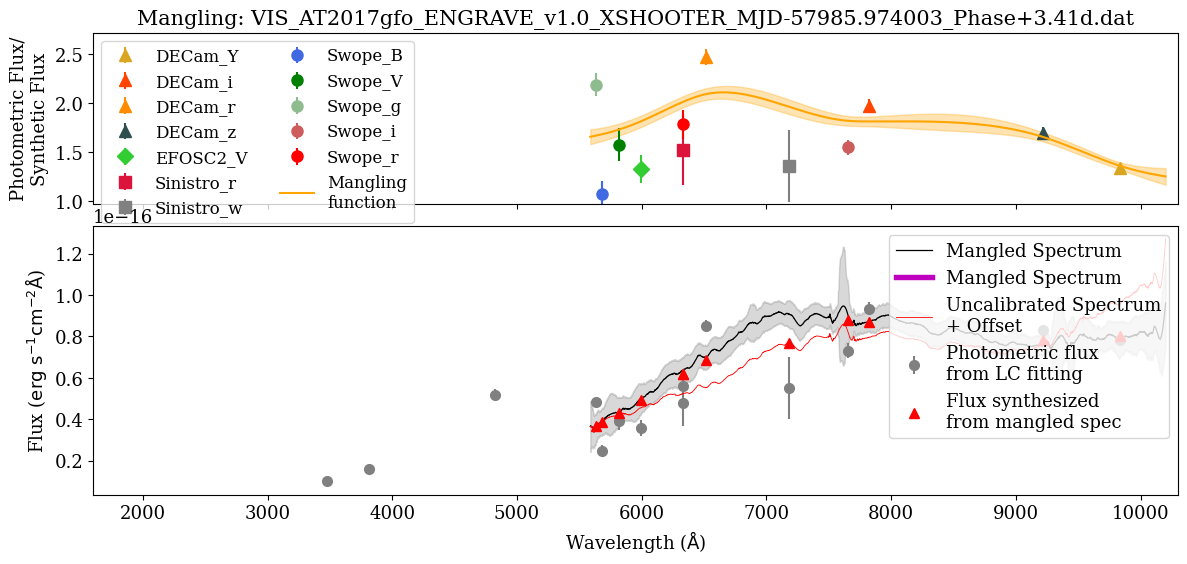

In [13]:
spec= SingleSpectrumClass(snname=snname, spec_file=list_[14], verbose=False)
spec.load_raw_spec()
result = spec.mangle_spectrum_function(show=True)


Checking filter: EFOSC2_U
  - min_mjd: 57984.0481, max_mjd: 57984.0559
  - Spectrum MJD: 57983.0362
  - Spectrum MJD 57983.0362 not in [57984.0481, 57984.0559] for EFOSC2_U, skipping.

Checking filter: EFOSC2_V
  - min_mjd: 57983.964, max_mjd: 57986.0531
  - Spectrum MJD: 57983.0362
  - Spectrum MJD 57983.0362 not in [57983.964, 57986.0531] for EFOSC2_V, skipping.

Checking filter: FourStar_H
  - min_mjd: 57982.9902, max_mjd: 57984.9714
  - Spectrum MJD: 57983.0362
  - Filter FourStar_H PASSES all checks.
  - fitted_phot: 3.3814434537327857e-17, fitted_phot_err: 2.6606699936111504e-18

Checking filter: FourStar_J
  - min_mjd: 57983.0, max_mjd: 57985.9728
  - Spectrum MJD: 57983.0362
  - Filter FourStar_J PASSES all checks.
  - fitted_phot: 7.981631214776204e-17, fitted_phot_err: 4.081376812664182e-18

Checking filter: FourStar_J1
  - min_mjd: 57984.0022, max_mjd: 57984.9801
  - Spectrum MJD: 57983.0362
  - Spectrum MJD 57983.0362 not in [57984.0022, 57984.9801] for FourStar_J1, skippi

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_45273/1122813917.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_45273/3738421891.py:137: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_raw_spec['flux'], cut_raw_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_45273/3738421891.py:139: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_raw_spec['fluxerr'])**2,


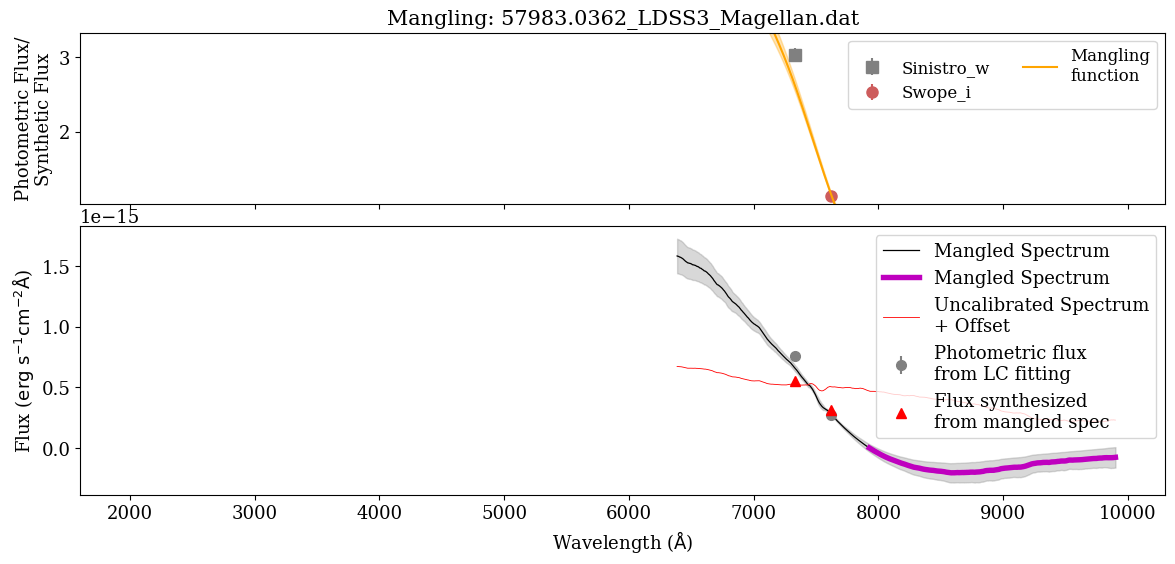

In [14]:
spec = SingleSpectrumClass(snname=snname, spec_file=list_[2], verbose=False)
spec.load_raw_spec()
if spec.phot4mangling is not None and not spec.phot4mangling.empty:
	result = spec.mangle_spectrum_function(show=True)
else:
	print(f"No photometry found for mangling for file: {list_[2]}")

## Mangle ALL spectra and show the series of mangled specs
#### Results from each single mangling are shown in ./Outputs/SNname/mangled/


Checking filter: ACS_WFC_F475W
  - min_mjd: 57992.4335, max_mjd: 57992.4335
  - Only one photometry point for ACS_WFC_F475W, skipping.

Checking filter: ACS_WFC_F625W
  - min_mjd: 57992.498, max_mjd: 57992.498
  - Only one photometry point for ACS_WFC_F625W, skipping.

Checking filter: ACS_WFC_F775W
  - min_mjd: 57992.5606, max_mjd: 57992.5606
  - Only one photometry point for ACS_WFC_F775W, skipping.

Checking filter: ACS_WFC_F850W
  - min_mjd: 57992.5732, max_mjd: 57992.5732
  - Only one photometry point for ACS_WFC_F850W, skipping.

Checking filter: DECam_Y
  - min_mjd: 57983.0030595, max_mjd: 58000.9782986
  - Spectrum MJD: 57987.03511
  - Filter DECam_Y PASSES all checks.
  - fitted_phot: 6.08548703112112e-17, fitted_phot_err: 1.9282220146339818e-18

Checking filter: DECam_g
  - min_mjd: 57983.0030595, max_mjd: 58000.9782986
  - Spectrum MJD: 57987.03511
  - Filter DECam_g PASSES all checks.
  - fitted_phot: 2.6867598580158417e-17, fitted_phot_err: 2.5958088442513322e-18

Checkin

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_60921/1122813917.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_60921/3738421891.py:137: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_raw_spec['flux'], cut_raw_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_60921/3738421891.py:139: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_raw_spec['fluxerr'])**2,


True
[(5252.9, 2.69448714e-17, 1.61184020e-17)
 (5254.8, 2.68752124e-17, 1.61028079e-17)
 (5256.8, 2.67535579e-17, 1.58790672e-17) ...
 (9795.6, 7.54983596e-17, 5.06558243e-17)
 (9797.6, 7.58623690e-17, 5.09735985e-17)
 (9801.5, 7.82891863e-17, 5.04365004e-17)]

Checking filter: ACS_WFC_F475W
  - min_mjd: 57992.4335, max_mjd: 57992.4335
  - Only one photometry point for ACS_WFC_F475W, skipping.

Checking filter: ACS_WFC_F625W
  - min_mjd: 57992.498, max_mjd: 57992.498
  - Only one photometry point for ACS_WFC_F625W, skipping.

Checking filter: ACS_WFC_F775W
  - min_mjd: 57992.5606, max_mjd: 57992.5606
  - Only one photometry point for ACS_WFC_F775W, skipping.

Checking filter: ACS_WFC_F850W
  - min_mjd: 57992.5732, max_mjd: 57992.5732
  - Only one photometry point for ACS_WFC_F850W, skipping.

Checking filter: DECam_Y
  - min_mjd: 57983.0030595, max_mjd: 58000.9782986
  - Spectrum MJD: 57983.01825
  - Filter DECam_Y PASSES all checks.
  - fitted_phot: 1.10499865880209e-16, fitted_phot_

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_60921/1122813917.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_60921/3738421891.py:137: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_raw_spec['flux'], cut_raw_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_60921/3738421891.py:139: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_raw_spec['fluxerr'])**2,



Checking filter: ACS_WFC_F475W
  - min_mjd: 57992.4335, max_mjd: 57992.4335
  - Only one photometry point for ACS_WFC_F475W, skipping.

Checking filter: ACS_WFC_F625W
  - min_mjd: 57992.498, max_mjd: 57992.498
  - Only one photometry point for ACS_WFC_F625W, skipping.

Checking filter: ACS_WFC_F775W
  - min_mjd: 57992.5606, max_mjd: 57992.5606
  - Only one photometry point for ACS_WFC_F775W, skipping.

Checking filter: ACS_WFC_F850W
  - min_mjd: 57992.5732, max_mjd: 57992.5732
  - Only one photometry point for ACS_WFC_F850W, skipping.

Checking filter: DECam_Y
  - min_mjd: 57983.0030595, max_mjd: 58000.9782986
  - Spectrum MJD: 57983.02788
  - Filter DECam_Y PASSES all checks.
  - fitted_phot: 1.1167378365889584e-16, fitted_phot_err: 4.1198166328074534e-18

Checking filter: DECam_g
  - min_mjd: 57983.0030595, max_mjd: 58000.9782986
  - Spectrum MJD: 57983.02788
  - Filter DECam_g PASSES all checks.
  - fitted_phot: 8.546587198644286e-16, fitted_phot_err: 3.032253794779219e-17

Checkin

...


Checking filter: ACS_WFC_F475W
  - min_mjd: 57992.4335, max_mjd: 57992.4335
  - Only one photometry point for ACS_WFC_F475W, skipping.

Checking filter: ACS_WFC_F625W
  - min_mjd: 57992.498, max_mjd: 57992.498
  - Only one photometry point for ACS_WFC_F625W, skipping.

Checking filter: ACS_WFC_F775W
  - min_mjd: 57992.5606, max_mjd: 57992.5606
  - Only one photometry point for ACS_WFC_F775W, skipping.

Checking filter: ACS_WFC_F850W
  - min_mjd: 57992.5732, max_mjd: 57992.5732
  - Only one photometry point for ACS_WFC_F850W, skipping.

Checking filter: DECam_Y
  - min_mjd: 57983.0030595, max_mjd: 58000.9782986
  - Spectrum MJD: 57993.000002
  - Filter DECam_Y PASSES all checks.
  - fitted_phot: 4.5279814254348695e-18, fitted_phot_err: 1.7208129576942754e-19

Checking filter: DECam_g
  - min_mjd: 57983.0030595, max_mjd: 58000.9782986
  - Spectrum MJD: 57993.000002
  - Filter DECam_g PASSES all checks.
  - fitted_phot: 2.6407787600759653e-18, fitted_phot_err: 1.6399373620740812e-19

Che

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_60921/1122813917.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_60921/3738421891.py:137: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_raw_spec['flux'], cut_raw_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_60921/3738421891.py:139: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_raw_spec['fluxerr'])**2,


Checking filter name: DECam_g
Checking filter name: DECam_r
Checking filter name: DECam_u
Checking filter name: UVOT_U

Checking filter: ACS_WFC_F475W
  - min_mjd: 57992.4335, max_mjd: 57992.4335
  - Only one photometry point for ACS_WFC_F475W, skipping.

Checking filter: ACS_WFC_F625W
  - min_mjd: 57992.498, max_mjd: 57992.498
  - Only one photometry point for ACS_WFC_F625W, skipping.

Checking filter: ACS_WFC_F775W
  - min_mjd: 57992.5606, max_mjd: 57992.5606
  - Only one photometry point for ACS_WFC_F775W, skipping.

Checking filter: ACS_WFC_F850W
  - min_mjd: 57992.5732, max_mjd: 57992.5732
  - Only one photometry point for ACS_WFC_F850W, skipping.

Checking filter: DECam_Y
  - min_mjd: 57983.0030595, max_mjd: 58000.9782986
  - Spectrum MJD: 57993.000003
  - Filter DECam_Y PASSES all checks.
  - fitted_phot: 4.5279806220187064e-18, fitted_phot_err: 1.7208652126689161e-19

Checking filter: DECam_g
  - min_mjd: 57983.0030595, max_mjd: 58000.9782986
  - Spectrum MJD: 57993.000003
  - 

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_60921/1122813917.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_60921/3738421891.py:137: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_raw_spec['flux'], cut_raw_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_60921/3738421891.py:139: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_raw_spec['fluxerr'])**2,



Checking filter: WFC3_IR_F110W
  - min_mjd: 57987.319, max_mjd: 57993.079
  - Spectrum MJD: 57993.000003
  - Filter WFC3_IR_F110W PASSES all checks.
  - fitted_phot: 6.860965372807474e-18, fitted_phot_err: 6.780177603989543e-19

Checking filter: WFC3_IR_F160W
  - min_mjd: 57987.452, max_mjd: 57993.148
  - Spectrum MJD: 57993.000003
  - Filter WFC3_IR_F160W PASSES all checks.
  - fitted_phot: 4.667819971523378e-18, fitted_phot_err: 6.021923009818856e-19

Checking filter: WFC3_UVIS1_F336W
  - min_mjd: 57992.3478, max_mjd: 57992.3478
  - Only one photometry point for WFC3_UVIS1_F336W, skipping.
Number of valid filters used: 5
Used filters: ['DECam_Y' 'DECam_i' 'DECam_r' 'DECam_z' 'WFC3_IR_F110W']
Ratios: [1.44510202 1.40814538 1.12223961 1.51730055 2.25344644]
Wavelengths: [9707.94234998 7812.81097469 6399.30785854 9165.81931817 9465.72991431]
Ratios errors: [0.0549213  0.07713321 0.06131838 0.07742157 0.22269121]
This spectrum has a huge amount of data points(18705), Im chopping a 3 th 

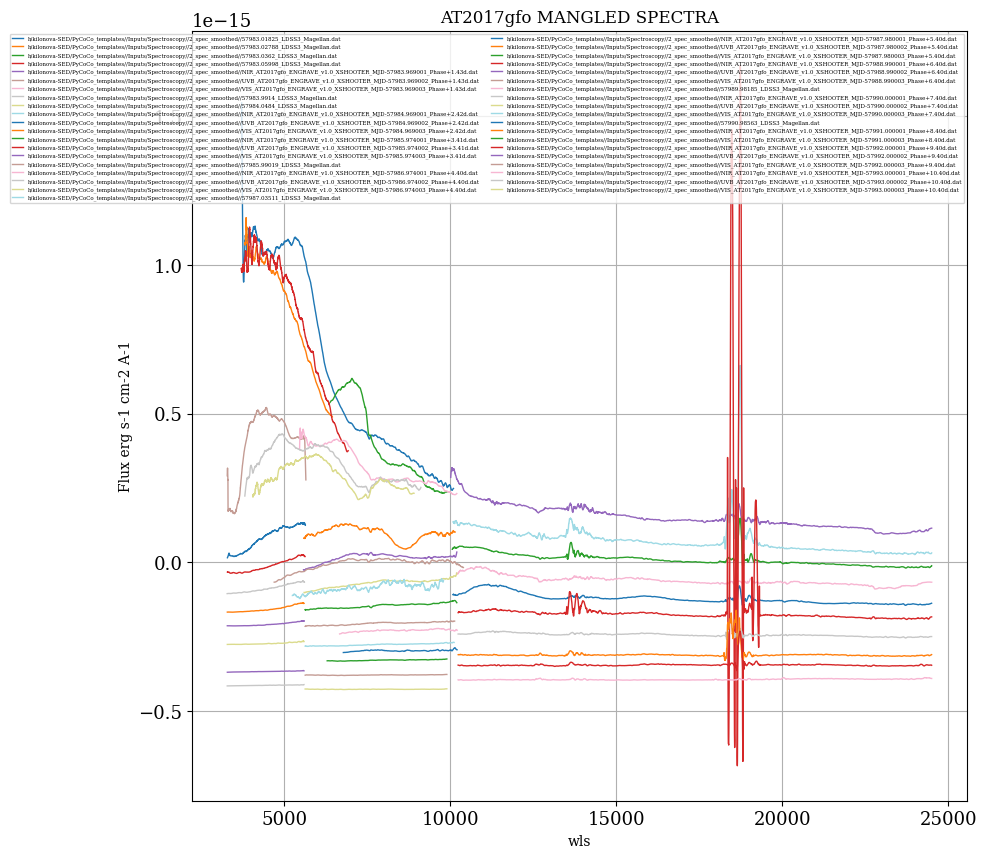


All spectra were successfully mangled.


In [17]:
plot_all_mangledspecs(spec_class)